## Lab 5: Feature Engineering

### 1. Setup and Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

sns.set(style="whitegrid")
pd.set_option("display.max_columns", None)

### 2. Data Loading and Initial Cleaning

In [2]:
DATA_PATH = "talabat_enhanced_orders2.csv" 
df = pd.read_csv(DATA_PATH)

# Drop leakage features
drop_leakage = ["Delivery_Time", "Delivery_Duration_Minutes"]
df = df.drop(columns=[c for c in drop_leakage if c in df.columns])
df_fe = df.copy()

### 3. Feature Engineering 

In [3]:
# 1. Time Features
df_fe["Order_Time"] = pd.to_datetime(df_fe["Order_Time"], errors="coerce")
df_fe["order_hour"] = df_fe["Order_Time"].dt.hour
df_fe["order_dayofweek"] = df_fe["Order_Time"].dt.dayofweek
df_fe["is_weekend"] = df_fe["order_dayofweek"].isin([5,6]).astype(int)

# 2. Price Features
df_fe["price_per_item"] = df_fe["Total_Price"] / df_fe["Quantity"]
df_fe["price_tier"] = pd.cut(df_fe["Total_Price"], bins=[0, 100, 250, 500, np.inf], labels=["low","medium","high","very_high"])

# 3. Distance (Haversine)
def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2.0)**2
    return R * 2 * np.arcsin(np.sqrt(a))

df_fe["dist_km"] = haversine_km(df_fe["Restaurant_Lat"], df_fe["Restaurant_Lon"], df_fe["Customer_Lat"], df_fe["Customer_Lon"])

### 4. Categorical Reduction *

In [12]:
top_k = 10

top_items = df_fe["Item_Name"].value_counts().head(top_k).index
df_fe["Item_Name_reduced"] = np.where(df_fe["Item_Name"].isin(top_items), df_fe["Item_Name"], "Other")

print(f"Current Experiment: top_k = {top_k}")

Current Experiment: top_k = 10


### 5. Model Training and Evaluation

In [13]:
# Select Features
target = "Order_Status"
ignore = ["Order_ID", "User_ID", "Restaurant_ID", "Driver_ID", "Order_Time", "Item_Name", "Total_Price", target]
X = df_fe.drop(columns=[c for c in ignore if c in df_fe.columns])
y = df_fe[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Preprocessing
cat_cols = X.select_dtypes(include=["object", "category", "str"]).columns.tolist()
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()

preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ("num", "passthrough", num_cols)
])

# Model Pipeline
model = Pipeline([
    ("prep", preprocessor),
    ("rf", RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
])

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(f"Accuracy for k = {top_k}:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy for k = 10: 0.3866
              precision    recall  f1-score   support

   Cancelled       0.38      0.47      0.42      1963
   Delivered       0.40      0.50      0.44      2039
  In Transit       0.18      0.01      0.02       998

    accuracy                           0.39      5000
   macro avg       0.32      0.32      0.29      5000
weighted avg       0.35      0.39      0.35      5000



### 6. Visualization (Feature Importance)

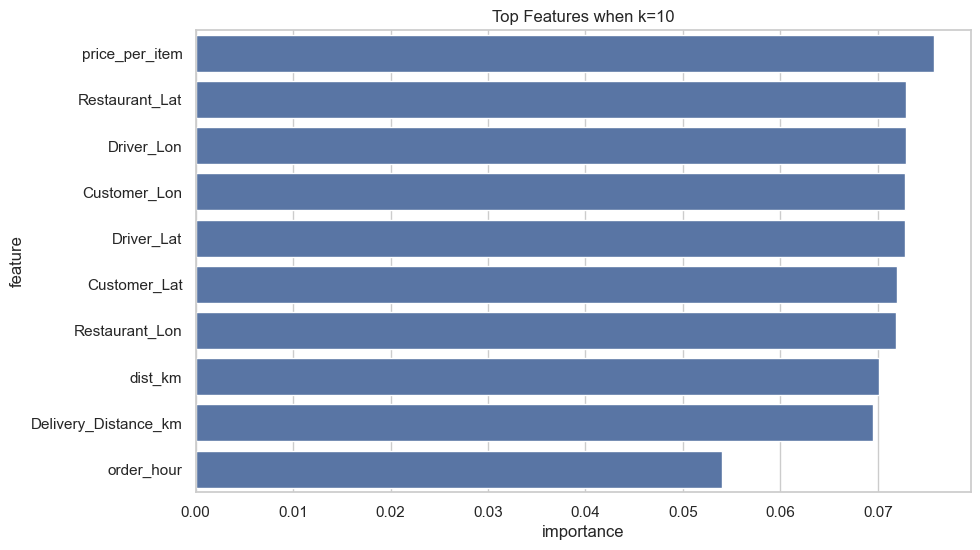

In [14]:
# Extract feature names and importances
ohe_names = model.named_steps["prep"].named_transformers_["cat"].get_feature_names_out(cat_cols)
feature_names = np.concatenate([ohe_names, num_cols])
importances = model.named_steps["rf"].feature_importances_

fi = pd.DataFrame({"feature": feature_names, "importance": importances}).sort_values("importance", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=fi.head(10), x="importance", y="feature")
plt.title(f"Top Features when k={top_k}")
plt.show()